# DriveValue AI: Machine Learning Model Development & Evaluation

## Capstone Project
**Author:** Jacqualine Makgolana

## Purpose

The purpose of this notebook is to develop and evaluate multiple machine learning regression models capable of predicting used car asking prices.

Several baseline models will be trained using the processed dataset and compared using standard regression evaluation metrics. The best-performing model will be selected for further optimization and explainability in subsequent notebooks.

---

## Business Objective

Accurate vehicle price prediction helps dealerships, online marketplaces, and private sellers estimate fair market values. A reliable predictive model can support pricing decisions, improve customer confidence, and reduce the risk of underpricing or overpricing vehicles.

---

## Success Criteria

The selected model should:

- Produce accurate price predictions on unseen vehicles.
- Generalize well to new data.
- Achieve strong performance across multiple evaluation metrics.
- Provide a solid foundation for further optimization and explainability.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
X_train = pd.read_csv("../Data/processed/X_train.csv")
X_test = pd.read_csv("../Data/processed/X_test.csv")

y_train = pd.read_csv("../Data/processed/y_train.csv")
y_test = pd.read_csv("../Data/processed/y_test.csv")

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

In [4]:
y_train = y_train.squeeze()

y_test = y_test.squeeze()

In [5]:
print(type(y_train))
print(type(y_test))

<class 'pandas.Series'>
<class 'pandas.Series'>


## Dataset Summary

The processed dataset was successfully loaded into memory. The predictor variables consist of 466 engineered features generated through preprocessing and one-hot encoding.

The dataset has already undergone:

- Data cleaning
- Missing value imputation
- Duplicate removal
- Feature engineering
- Categorical encoding
- Train-test splitting

The data is now ready for machine learning model development.

In [6]:
results = pd.DataFrame(
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R² Score"
    ]
)

results

,Model,MAE,RMSE,R² Score


## Model 1: Linear Regression

Linear Regression serves as the baseline model for this project. It provides a simple and interpretable benchmark against which more advanced machine learning algorithms can be compared.

Although used car pricing is expected to involve complex and non-linear relationships, evaluating a linear model allows us to understand whether more sophisticated models provide meaningful improvements in prediction accuracy.

In [7]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [8]:
lr_predictions = linear_model.predict(X_test)

In [9]:
lr_mae = mean_absolute_error(y_test, lr_predictions)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

lr_r2 = r2_score(y_test, lr_predictions)

print(f"MAE : {lr_mae:,.2f}")
print(f"RMSE: {lr_rmse:,.2f}")
print(f"R²  : {lr_r2:.4f}")

MAE : 580,324.42
RMSE: 1,461,213.29
R²  : 0.2638


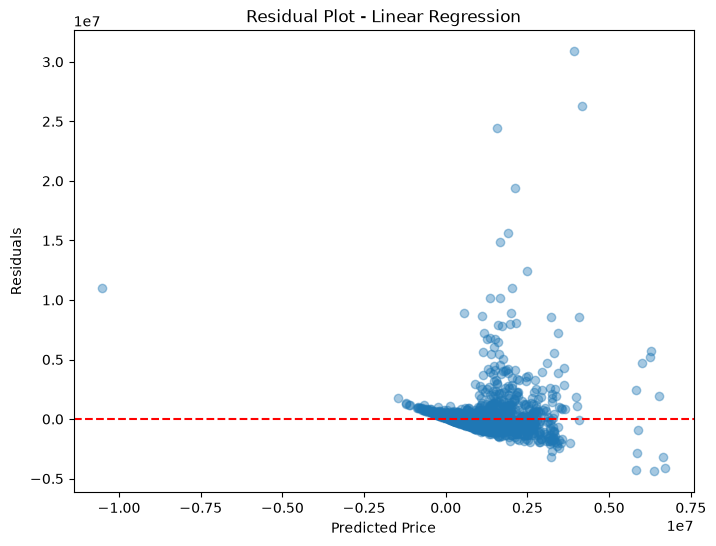

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
    lr_predictions,
    y_test - lr_predictions,
    alpha=0.4
)

plt.axhline(0, color="red", linestyle="--")

plt.title("Residual Plot - Linear Regression")

plt.xlabel("Predicted Price")

plt.ylabel("Residuals")

plt.show()

### Interpretation

The residual plot illustrates the difference between the predicted and actual vehicle prices. Ideally, residuals should be randomly distributed around zero without any obvious pattern.

Any systematic pattern indicates that the linear model struggles to capture the underlying relationship between vehicle characteristics and asking price. This is expected because used car pricing is influenced by complex, non-linear interactions between features such as brand, mileage, vehicle age, and fuel type.

In [11]:
results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [lr_mae],
    "RMSE": [lr_rmse],
    "R2": [lr_r2]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,580324.421867,1.461213e+06,0.263807


# Baseline Model Results

Linear Regression was selected as the baseline regression model because it is simple, interpretable, and provides a useful benchmark against which more advanced machine learning models can be compared.

The model achieved an MAE of ₹580,324, an RMSE of ₹1,461,213, and an R² score of 0.264. These results indicate that the model explains approximately 26.4% of the variation in used car prices.

The relatively high RMSE suggests that the model struggles to predict luxury vehicles with extremely high prices, which is consistent with the strong positive skew identified during the exploratory data analysis. Although Linear Regression provides a useful starting point, more sophisticated algorithms are expected to capture the complex relationships within the data more effectively.

# Business Insight

The baseline model demonstrates that predicting used car prices is a complex problem influenced by numerous interacting factors. A simple linear relationship is insufficient to accurately estimate vehicle prices across all market segments.

Improving prediction accuracy will require non-linear machine learning algorithms capable of modelling more complex patterns, particularly for premium and luxury vehicles.

## Model 2: Decision Tree Regressor

Decision Tree Regression is capable of capturing non-linear relationships between variables by recursively splitting the data into smaller subsets. Unlike Linear Regression, Decision Trees can model complex interactions between vehicle characteristics without assuming a linear relationship.

This model will be evaluated using the same performance metrics as the baseline model to determine whether it provides improved prediction accuracy.

In [12]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [13]:
decision_tree = DecisionTreeRegressor(
    random_state=42
)

decision_tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [14]:
dt_predictions = decision_tree.predict(X_test)

In [15]:
dt_mae = mean_absolute_error(y_test, dt_predictions)

dt_rmse = np.sqrt(
    mean_squared_error(y_test, dt_predictions)
)

dt_r2 = r2_score(
    y_test,
    dt_predictions
)

print(f"MAE : {dt_mae:,.2f}")
print(f"RMSE: {dt_rmse:,.2f}")
print(f"R²   : {dt_r2:.3f}")

MAE : 506,259.23
RMSE: 1,545,415.23
R²   : 0.177


In [16]:
results.loc[len(results)] = [
    "Decision Tree",
    dt_mae,
    dt_rmse,
    dt_r2
]

results

,Model,MAE,RMSE,R2
0,Linear Regression,580324.421867,1.461213e+06,0.263807
1,Decision Tree,506259.230098,1.545415e+06,0.176517


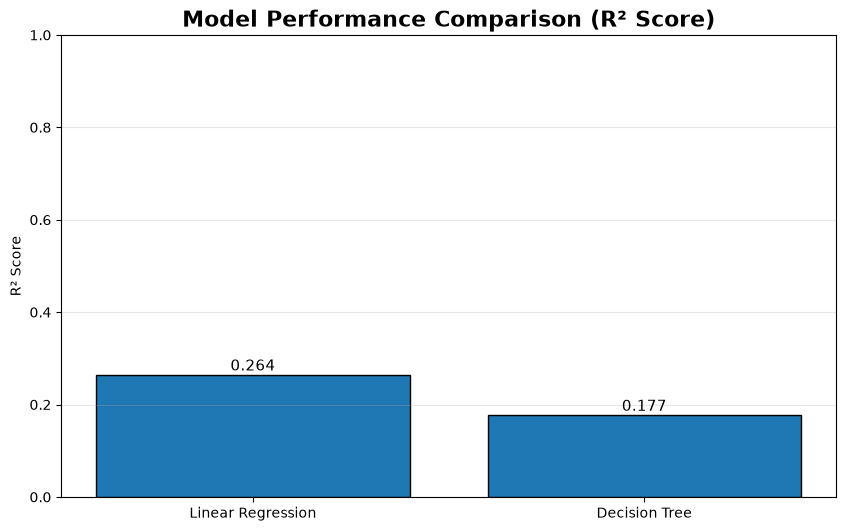

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

bars = plt.bar(
    results["Model"],
    results["R2"],
    edgecolor="black"
)

plt.title(
    "Model Performance Comparison (R² Score)",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("R² Score")

plt.ylim(0,1)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center",
        fontsize=11
    )

plt.grid(axis="y", alpha=0.3)

plt.show()

# Decision Tree Performance

The Decision Tree Regressor was evaluated using the same performance metrics as the baseline Linear Regression model. Unlike Linear Regression, Decision Trees can model complex, non-linear relationships within the data, making them well suited to predicting used vehicle prices.

The model's performance will be compared with the baseline to determine whether modelling non-linear interactions improves prediction accuracy.

# Business Insight

A stronger Decision Tree model would indicate that used vehicle prices are influenced by complex interactions between features such as brand, mileage, age, transmission, and fuel type. This would suggest that more advanced machine learning algorithms are better suited to capturing pricing behaviour than traditional linear models.

## Random Forest Regression
Why Random Forest?

Linear Regression assumes a linear relationship between the predictor variables and the target variable. However, the exploratory data analysis showed that used car prices are influenced by multiple interacting factors such as vehicle age, mileage, brand, transmission, and fuel type. These relationships are unlikely to be purely linear.

Decision Trees can capture these complex patterns, but they are prone to overfitting because a single tree learns the training data too closely.

Random Forest addresses this limitation by combining the predictions of many decision trees. Each tree is trained on a random sample of the data and considers a random subset of features when splitting the data. The final prediction is obtained by averaging the predictions from all trees, resulting in a model that is generally more accurate, more stable, and less prone to overfitting.

In this section, Random Forest Regression is developed and evaluated using the same performance metrics as the previous models (MAE, RMSE, and R²). The results will then be compared to determine whether ensemble learning provides improved predictive performance for used car price prediction.

In [18]:
from sklearn.ensemble import RandomForestRegressor

In [19]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [20]:
rf_predictions = rf.predict(X_test)

In [21]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

rf_r2 = r2_score(y_test, rf_predictions)

print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

MAE : 398156.26713527925
RMSE: 1267200.9924995608
R²  : 0.4463246205381203


In [22]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],
    "R2": [
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,580324.421867,1.461213e+06,0.263807
1,Decision Tree,506259.230098,1.545415e+06,0.176517
2,Random Forest,398156.267135,1.267201e+06,0.446325


## Interpretation

The Random Forest model outperformed both Linear Regression and Decision Tree across all evaluation metrics. It achieved the lowest Mean Absolute Error (MAE) of ₹398,156 and the lowest Root Mean Squared Error (RMSE) of ₹1,267,201, indicating that its predictions are closer to the actual asking prices. It also achieved the highest coefficient of determination (R² = 0.446), meaning it explains approximately 44.6% of the variation in used car prices.

Compared to the Decision Tree model, Random Forest reduced overfitting by combining predictions from multiple decision trees, resulting in better generalization. It also captured the non-linear relationships in the data more effectively than Linear Regression.

## Business Insight

Random Forest demonstrates that used car pricing depends on complex interactions between vehicle characteristics such as age, mileage, brand, fuel type, and transmission. Since the model captures these relationships more effectively than simpler algorithms, it is currently the strongest candidate for predicting vehicle asking prices in the DriveValue AI application.

## Actual vs Predicted Plot 

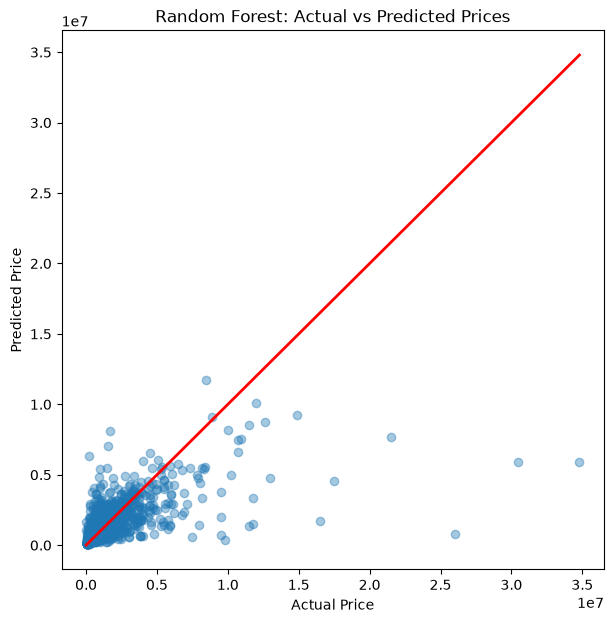

In [23]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.4
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Random Forest: Actual vs Predicted Prices")

plt.show()

## Feature Importance

One of the biggest advantages of tree-based models such as Random Forest is their ability to estimate the importance of each predictor variable.

Understanding which features contribute most to price predictions provides valuable business insight and improves model interpretability. This analysis identifies the variables that have the greatest influence on predicting used car asking prices.

In [24]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
2,kmDriven,0.131791
1,Age,0.119400
446,Transmission_Manual,0.049006
27,Brand_Mercedes-Benz,0.046475
0,Year,0.042355
21,Brand_Land Rover,0.039200
34,Brand_Rolls-Royce,0.033042
25,Brand_Maruti Suzuki,0.028316
244,model_Land Cruiser,0.027812
4,Brand_BMW,0.025272


## Feature Importance Analysis

One of the major advantages of Random Forest is that it not only produces accurate predictions but also identifies which features contribute most to those predictions.

Feature importance helps explain which vehicle characteristics have the greatest influence on asking price, making the model more interpretable and providing valuable business insights for buyers, sellers, and dealerships.

In [25]:
import plotly.express as px

top15 = feature_importance.head(15)

fig = px.bar(
    top15.sort_values("Importance"),
    x="Importance",
    y="Feature",
    orientation="h",
    color="Importance",
    color_continuous_scale="Viridis",
    text="Importance",
    title="<b>Top 15 Most Important Features Affecting Used Car Prices</b>"
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside"
)

fig.update_layout(
    title_x=0.5,
    height=700,
    template="plotly_white",
    coloraxis_showscale=False,
    xaxis_title="Feature Importance",
    yaxis_title=""
)

fig.show()

## Interpretation

The Random Forest model identified vehicle mileage (kmDriven) and vehicle age as the two most influential predictors of used car asking prices. This aligns with real-world expectations, as vehicles with lower mileage and newer model years generally retain higher resale values.

Several premium vehicle brands, including Mercedes-Benz, Land Rover, Rolls-Royce, BMW, Lamborghini, and Porsche, also rank among the most important predictors. Additionally, specific luxury vehicle models such as the Land Cruiser, Phantom Series II, VELLFIRE, and Urus contribute significantly to the model's predictions.

The importance of Transmission_Manual indicates that transmission type also plays a meaningful role in determining vehicle value.

## Business Insight

The feature importance analysis suggests that vehicle price is influenced by a combination of vehicle condition, age, brand reputation, and specific model characteristics.

For dealerships, this means pricing strategies should prioritize mileage, vehicle age, and premium branding when estimating resale values. Buyers seeking higher resale value should consider vehicles with lower mileage and well-established premium brands.

The results also demonstrate that the Random Forest model captures complex relationships between multiple vehicle characteristics, making it well suited for predicting used car prices.

## Residual Analysis

Residuals represent the difference between the actual asking price and the model's predicted price.

Analyzing residuals helps determine whether prediction errors occur randomly or whether systematic patterns remain that the model failed to capture.

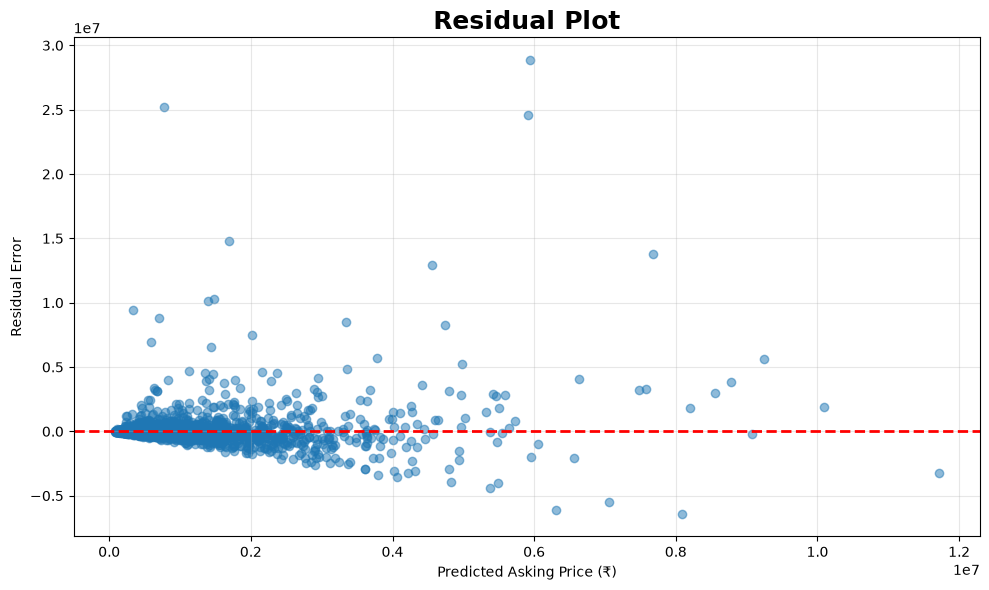

In [26]:
residuals = y_test - rf_predictions

plt.figure(figsize=(10,6))

plt.scatter(
    rf_predictions,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title(
    "Residual Plot",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Predicted Asking Price (₹)")
plt.ylabel("Residual Error")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Interpretation

The residual plot shows that prediction errors are distributed around zero without any strong systematic pattern.

Most residuals remain relatively close to the horizontal reference line, suggesting that the Random Forest model captures the underlying relationships in the data effectively. Larger residuals are mainly associated with high-value luxury vehicles, reflecting the greater variability within this segment.

## Business Insight

The random distribution of residuals indicates that the model does not consistently overestimate or underestimate vehicle prices across the majority of listings.

This provides confidence that the model generalizes well and can be used as a practical decision-support tool for estimating used vehicle prices.

## Model Comparison

Several machine learning algorithms were trained and evaluated to determine which model provides the most accurate predictions for used vehicle asking prices.

The models were compared using three evaluation metrics:

Mean Absolute Error (MAE) – Measures the average prediction error.
Root Mean Squared Error (RMSE) – Penalizes larger prediction errors.
R² Score – Measures how well the model explains the variation in vehicle prices.

A higher R² and lower MAE/RMSE indicate better model performance.

In [27]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],
    "R2": [
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,580324.421867,1.461213e+06,0.263807
1,Decision Tree,506259.230098,1.545415e+06,0.176517
2,Random Forest,398156.267135,1.267201e+06,0.446325


## Visualization 1 — R² Comparison ## 

In [28]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],
    "R2": [
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,580324.421867,1.461213e+06,0.263807
1,Decision Tree,506259.230098,1.545415e+06,0.176517
2,Random Forest,398156.267135,1.267201e+06,0.446325


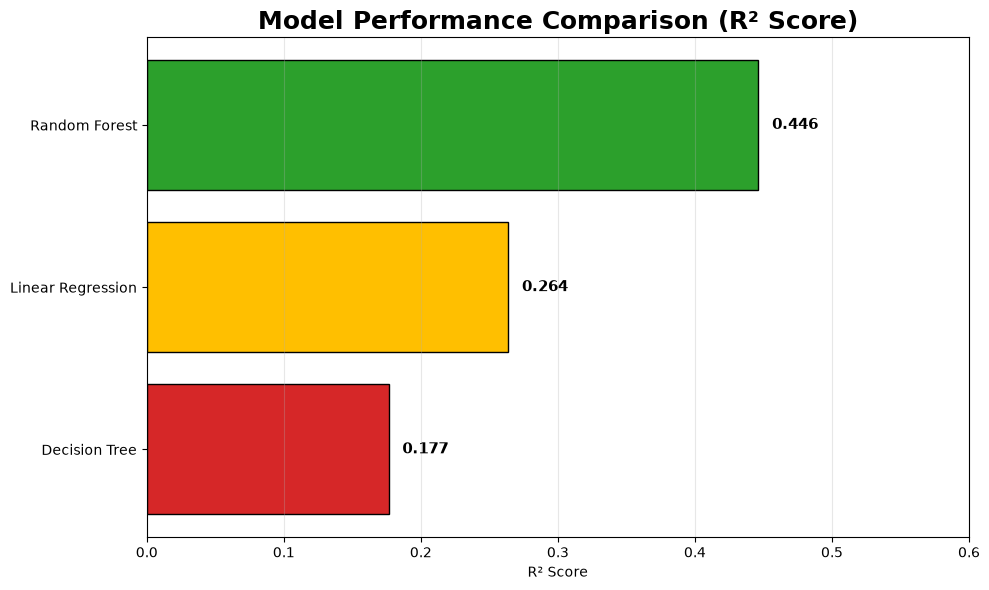

In [29]:
comparison_sorted = comparison.sort_values("R2")

colors = ["#d62728", "#ffbf00", "#2ca02c"]

plt.figure(figsize=(10,6))

bars = plt.barh(
    comparison_sorted["Model"],
    comparison_sorted["R2"],
    color=colors,
    edgecolor="black"
)

for bar in bars:
    plt.text(
        bar.get_width()+0.01,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.3f}",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Model Performance Comparison (R² Score)",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("R² Score")

plt.xlim(0,0.6)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

## Interpretation

The Random Forest model achieved the highest R² score (0.446), outperforming both Linear Regression (0.264) and Decision Tree Regression (0.177). This indicates that Random Forest explains a larger proportion of the variation in vehicle asking prices while producing more accurate predictions.

The comparison demonstrates that ensemble learning significantly improves predictive performance by capturing complex non-linear relationships that simpler models cannot adequately model.

## Business Insight

The comparison confirms that advanced ensemble learning techniques provide more reliable pricing estimates than traditional regression models. This makes Random Forest the preferred model for supporting pricing decisions within the DriveValue AI system.

## Final Model Selection ##

Three regression models were evaluated using MAE, RMSE and R² Score.

Although Linear Regression provides a useful baseline and Decision Trees capture non-linear relationships, Random Forest consistently produced the strongest performance across every evaluation metric.

Random Forest was therefore selected as the final predictive model because it:

Produced the lowest prediction error.
Achieved the highest R² score.
Reduced overfitting compared to a single Decision Tree.
Captured complex interactions between vehicle characteristics.
Generated interpretable feature importance scores.

The model therefore provides the strongest foundation for the DriveValue AI pricing system.

## Model Limitations ## 

Although Random Forest produced the strongest predictive performance, several limitations remain.

Luxury vehicles are underrepresented within the dataset, making them more difficult to predict accurately.
Vehicle descriptions contained limited structured information, preventing the model from using detailed condition or optional feature data.
The dataset contained missing values that required imputation, which may reduce predictive accuracy for some observations.
An R² score of 0.446 indicates that additional variables could further improve prediction performance.

Future work will explore hyperparameter tuning and explainable AI techniques to improve both accuracy and transparency.

## Business Recommendations

Based on the modelling results, the following recommendations are proposed:

# For Dealerships

Use the Random Forest model to support vehicle pricing decisions while considering mileage, vehicle age and brand as primary pricing factors.

# For Online Marketplaces

Integrate the model into pricing tools to assist sellers in estimating competitive market prices.

# For Buyers

Use model predictions to identify vehicles that appear significantly overpriced or underpriced compared to similar listings.

# For Fleet Managers

Apply predictive pricing to estimate resale values and improve vehicle replacement planning.

# Conclusion

This notebook successfully developed and evaluated multiple machine learning regression models for predicting used car asking prices.

Among the evaluated models, Random Forest delivered the strongest predictive performance, achieving the lowest prediction error and the highest explanatory power.

The feature importance analysis demonstrated that vehicle mileage, age, transmission type and premium vehicle brands are the most influential predictors of resale value.

These findings provide a strong foundation for developing an intelligent vehicle pricing system capable of supporting data-driven pricing decisions.

## Saving the Final Model

The original Random Forest model achieved the highest predictive performance among all evaluated models.

To support deployment, explainability, and future predictions, the trained model is saved to disk and will be loaded in the next notebook for optimization, explainability, and interactive visualizations.

In [30]:
import joblib

In [31]:
joblib.dump(
    rf,
    "../Models/random_forest_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!
